In [1]:
# Importing the required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import AdaBoostClassifier

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Loading the dataset

df = pd.read_csv(
    r"C:\Users\91958\Desktop\Machine Learning\datasets\Social_Network_Ads.csv"
)

# Display the first five rows

df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [3]:
# Displaying dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [4]:
# Statistical summary of numerical columns

df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [5]:
# Checking for missing values

df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [6]:
# Displaying dataset dimensions

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 400
Columns : 5


In [7]:
# Removing the User ID column (if it exists)

if "User ID" in df.columns:
    df = df.drop("User ID", axis=1)

# Selecting independent and dependent variables

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

print("\nFeatures Shape:", X.shape)
print("Target Shape:", y.shape)

Features:


,Gender,Age,EstimatedSalary
0,Male,19,19000
1,Male,35,20000
2,Female,26,43000
3,Female,27,57000
4,Male,19,76000



Target:


0    0
1    0
2    0
3    0
4    0
Name: Purchased, dtype: int64


Features Shape: (400, 3)
Target Shape: (400,)


In [8]:
# Encoding the Gender column

encoder = LabelEncoder()

X["Gender"] = encoder.fit_transform(X["Gender"])

print("Encoded Features:")
display(X.head())

print("\nEncoding Mapping:")
print("Female → 0")
print("Male → 1")

Encoded Features:


,Gender,Age,EstimatedSalary
0,1,19,19000
1,1,35,20000
2,0,26,43000
3,0,27,57000
4,1,19,76000



Encoding Mapping:
Female → 0
Male → 1


In [9]:
# Splitting the dataset into Training and Testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Labels :", y_train.shape)
print("Testing Labels :", y_test.shape)

Training Features : (300, 3)
Testing Features : (100, 3)
Training Labels : (300,)
Testing Labels : (100,)


In [10]:
# Feature Scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature Scaling completed successfully!")

print("\nTraining Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)

Feature Scaling completed successfully!

Training Features Shape: (300, 3)
Testing Features Shape: (100, 3)


In [11]:
# Training the AdaBoost Classification model

model = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

model.fit(X_train, y_train)

print("AdaBoost model trained successfully!")

AdaBoost model trained successfully!


In [12]:
# Predicting the test data

y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred[:10])

Predictions:
[1 1 0 1 0 0 1 0 0 0]


In [13]:
# Comparing Actual and Predicted values

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,0,1
1,1,1
2,0,0
3,1,1
4,0,0
5,0,0
6,1,1
7,0,0
8,0,0
9,0,0


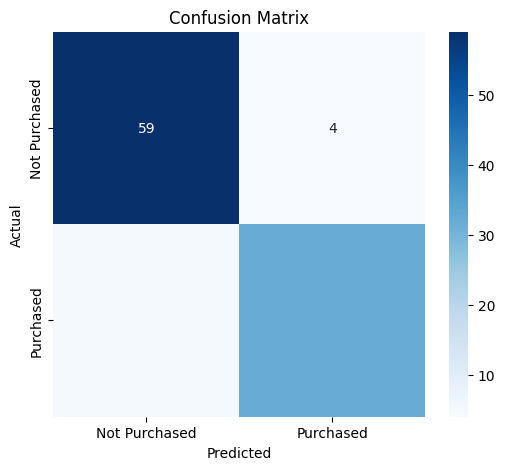

In [14]:
from sklearn.metrics import confusion_matrix

# Creating the Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Purchased", "Purchased"],
    yticklabels=["Not Purchased", "Purchased"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [15]:
from sklearn.metrics import accuracy_score

# Calculating Accuracy

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy Score: {accuracy:.2%}")

Accuracy Score: 91.00%


In [16]:
from sklearn.metrics import classification_report

# Displaying Classification Report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.94      0.93        63
           1       0.89      0.86      0.88        37

    accuracy                           0.91       100
   macro avg       0.91      0.90      0.90       100
weighted avg       0.91      0.91      0.91       100



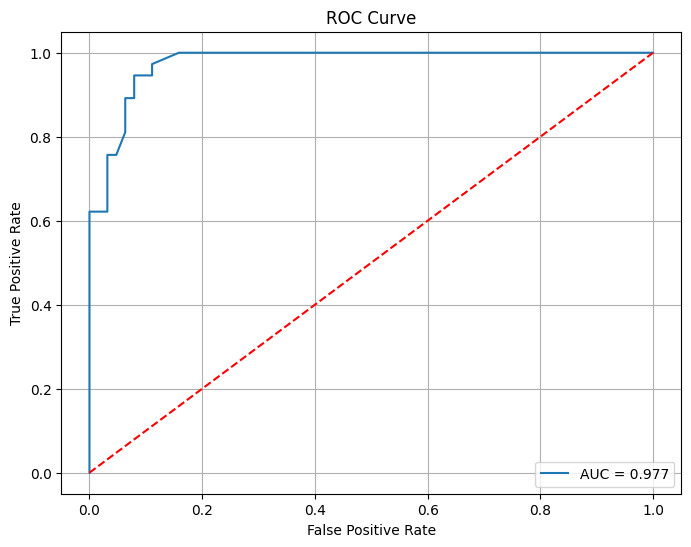

AUC Score: 0.9766194766194767


In [17]:
from sklearn.metrics import roc_curve, roc_auc_score

# Predicting probabilities

y_prob = model.predict_proba(X_test)[:, 1]

# Calculating ROC Curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")

plt.plot([0,1], [0,1], linestyle="--", color="red")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.grid(True)

plt.show()

print("AUC Score:", auc_score)

In [18]:
# Predicting a new customer's purchase

new_customer = pd.DataFrame({
    "Gender": [1],
    "Age": [35],
    "EstimatedSalary": [60000]
})

# Apply Feature Scaling

new_customer_scaled = scaler.transform(new_customer)

prediction = model.predict(new_customer_scaled)

if prediction[0] == 1:
    print("Prediction: Customer is likely to PURCHASE the product.")
else:
    print("Prediction: Customer is NOT likely to PURCHASE the product.")

Prediction: Customer is NOT likely to PURCHASE the product.


,Feature,Importance
2,EstimatedSalary,0.540494
1,Age,0.440966
0,Gender,0.018540


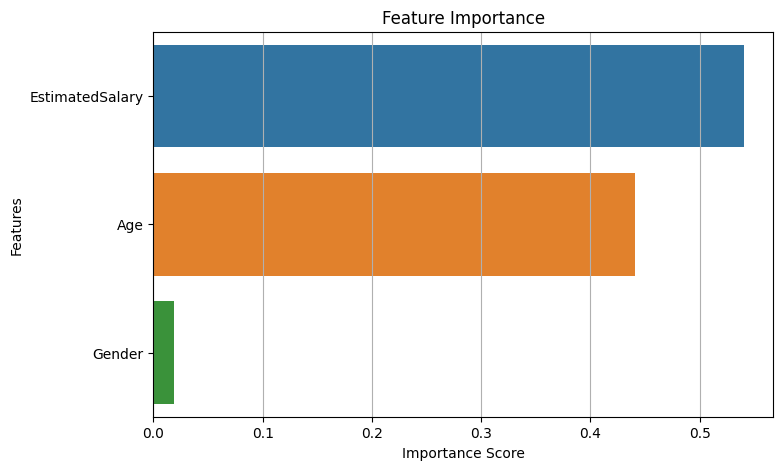

In [19]:
# Feature Importance

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

display(importance)

plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.grid(axis="x")

plt.show()

In [20]:
# Displaying AdaBoost Hyperparameters

parameters = pd.DataFrame({
    "Hyperparameter": model.get_params().keys(),
    "Value": model.get_params().values()
})

display(parameters)

,Hyperparameter,Value
0,algorithm,deprecated
1,estimator,None
2,learning_rate,1.0
3,n_estimators,100
4,random_state,42
